# Exercise 11

## 1.3

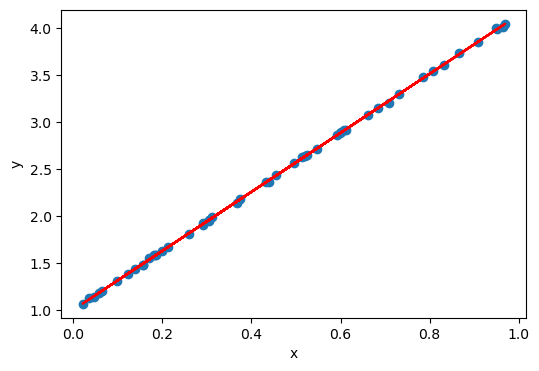

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 50
x = np.random.uniform(0,1,N)
epsilon = np.random.normal(0,0.1,N)
y = np.pi * x + 1 + 0.1 * epsilon

sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xx = np.sum(x * x)
sum_xy = np.sum(x * y)

m = (N * sum_xy - sum_x * sum_y) / (N * sum_xx - sum_x**2)
b = (sum_y - m * sum_x) / N

plt.figure(figsize=(6,4), label='Training data')
plt.plot(x, m*x + b, color='red', label=f'Best fit line: y={m:.2f}x+{b:.2f}')
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Task 2


## 2.1

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 10000
m = 100
beta_true = np.random.normal(0, 1, m)

X = np.random.uniform(0, 1, (n, m))
noise = np.random.normal(0, 0.1, n)
y = np.dot(X, beta_true) + noise

## 2.2 Regression

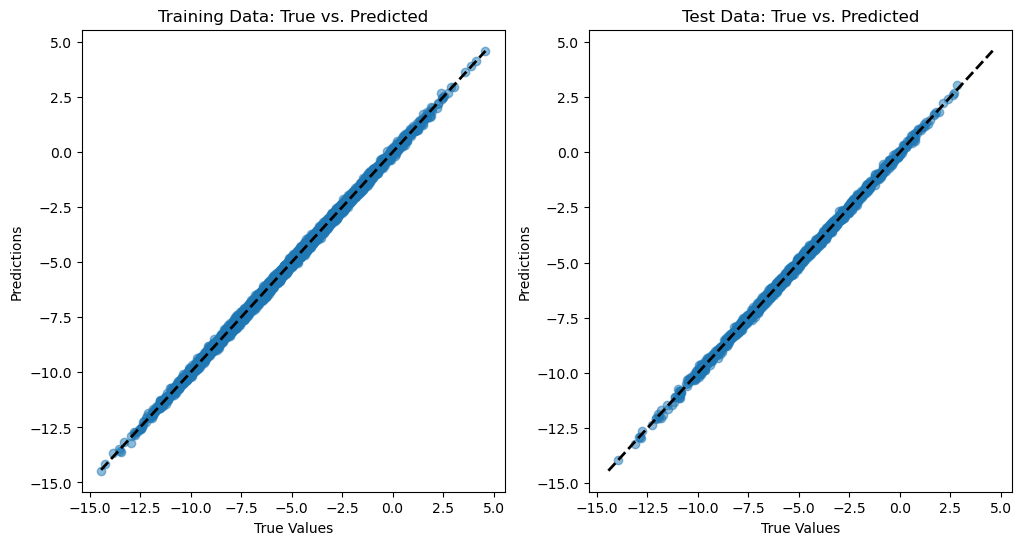

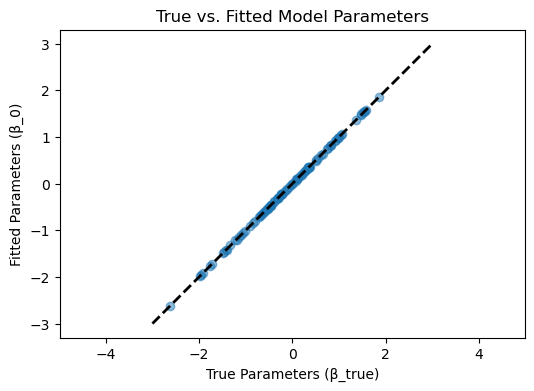

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.title('Training Data: True vs. Predicted')
plt.xlabel('True Values')
plt.ylabel('Predictions')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.title('Test Data: True vs. Predicted')
plt.xlabel('True Values')
plt.ylabel('Predictions')

plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(beta_true, model.coef_, alpha=0.5)
plt.plot([-3, 3], [-3, 3], 'k--', lw=2)
plt.title('True vs. Fitted Model Parameters')
plt.xlabel('True Parameters (β_true)')
plt.ylabel('Fitted Parameters (β_0)')
plt.axis('equal')
plt.show()

# Task 3

## Task 3.1

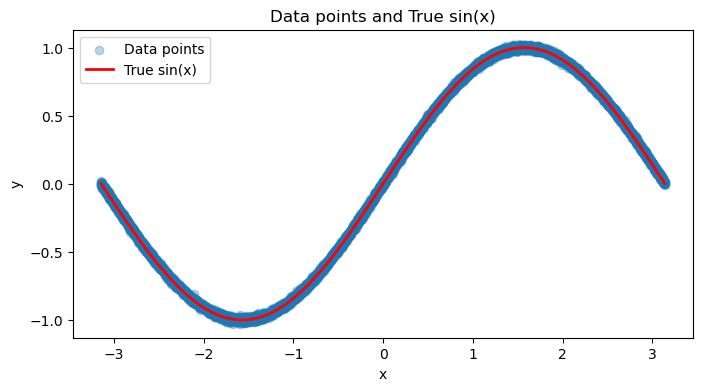

In [24]:
np.random.seed(42)

n = 10000
x = np.random.uniform(-np.pi, np.pi, n)
epsilon = np.random.normal(0, 0.1, n)
y = np.sin(x) + 0.1 * epsilon

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.3, label='Data points')
plt.plot(np.sort(x), np.sin(np.sort(x)), color='red', linewidth=2, label='True sin(x)')
plt.title('Data points and True sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Task 3.2

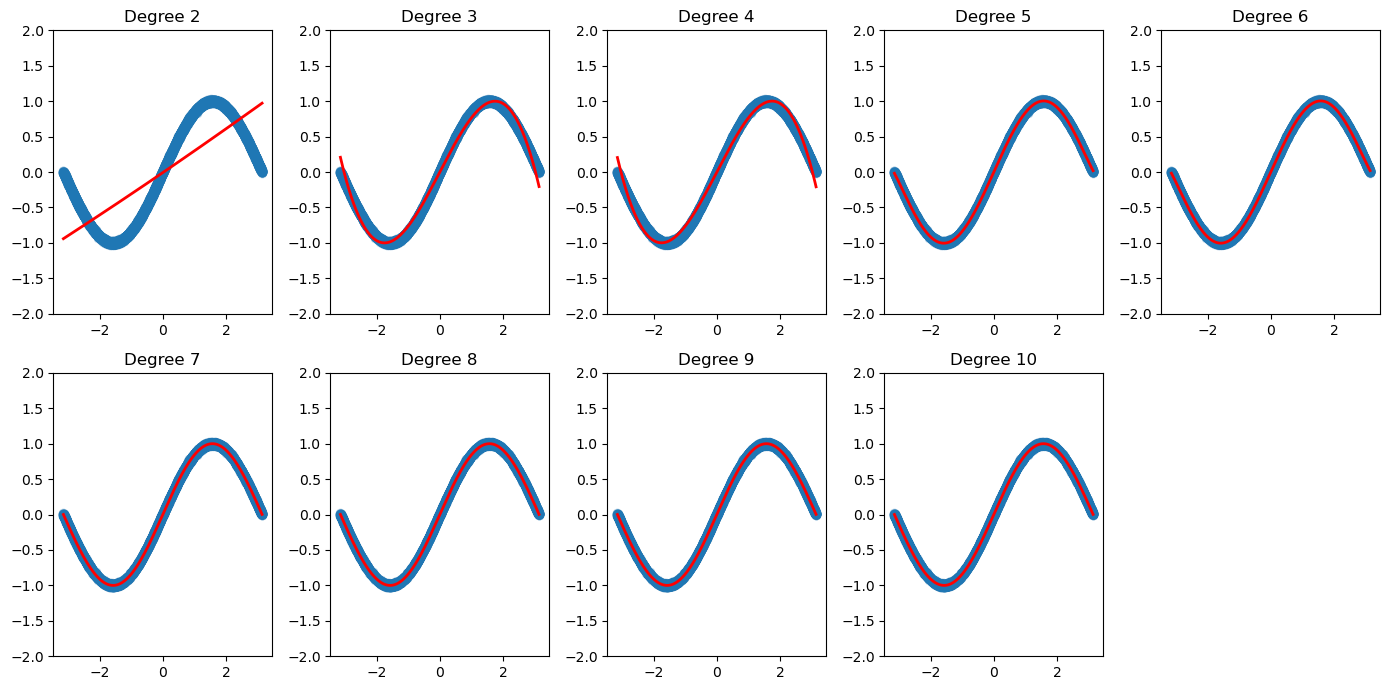

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = range(2, 11)
plt.figure(figsize=(14, 7))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x[:, np.newaxis], y)
    y_pred = model.predict(np.sort(x)[:, np.newaxis])

    plt.subplot(2, 5, i + 1)
    plt.scatter(x, y, alpha=0.3)
    plt.plot(np.sort(x), y_pred, color='red', linewidth=2)
    plt.title(f'Degree {degree}')
    plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

## Task 3.3

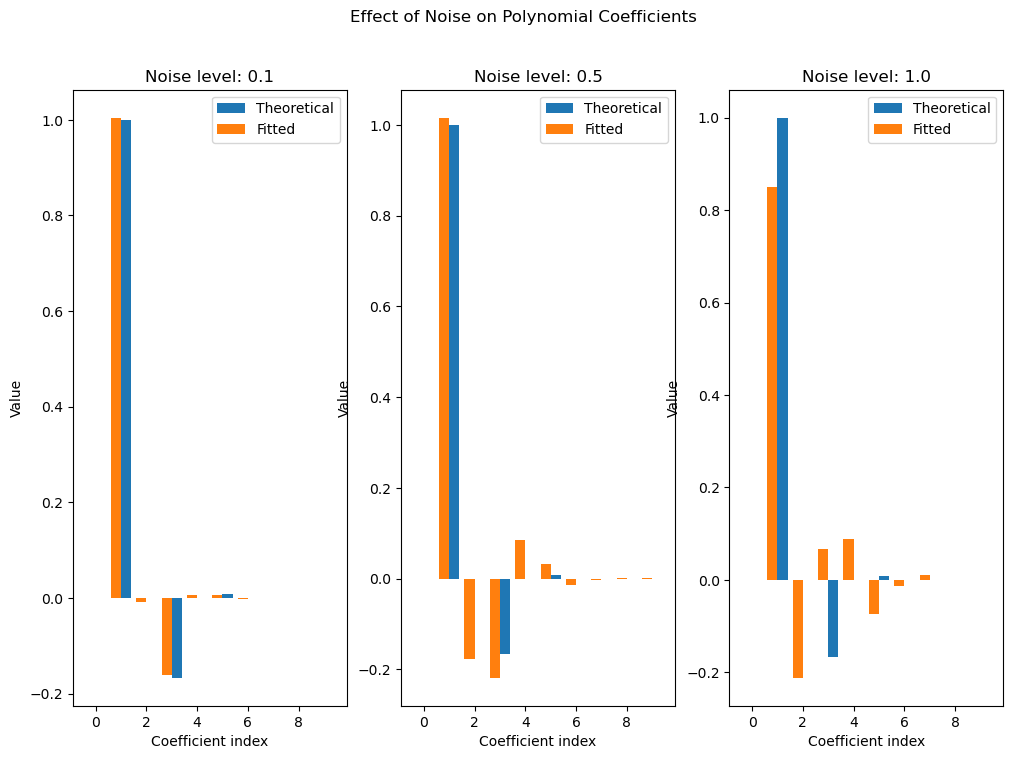

In [34]:
def fit_model(x, y, degree=9):
    """Fit a polynomial regression model and get coefficients."""
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    model = LinearRegression()
    model.fit(X_poly, y)
    return model.coef_

# Constants
n = 1000  # Number of data points
degrees = 9  # Degree of polynomial
noise_levels = [0.1, 0.5, 1.0]  # Different levels of noise to test

theoretical_coeffs = [0, 1, 0, -1/6, 0, 1/120, 0, -1/5040, 0, 1/362880]

plt.figure(figsize=(12, 8))
for i, noise in enumerate(noise_levels):
    x, y = generate_data(n, noise)
    coeffs = fit_model(x, y, degrees)
    plt.subplot(1, len(noise_levels), i + 1)
    plt.bar(range(len(theoretical_coeffs)), theoretical_coeffs, width=0.4, label='Theoretical', align='edge')
    plt.bar(range(len(coeffs)), coeffs, width=-0.4, label='Fitted', align='edge')
    plt.title(f'Noise level: {noise}')
    plt.xlabel('Coefficient index')
    plt.ylabel('Value')
    plt.legend()

plt.suptitle('Effect of Noise on Polynomial Coefficients')
plt.show()


## Interpretation of plots

To evaluate the model we have to look at the alignment between the blue (theoretical) bar and the orange one.
A close alignment indicated a high accuracy.

When increasing the alignment becomes worse, due to the model fitting for the noise. It is sort of overfitting
for the noise, making it a worse representation for the actual function. The discrepancy might change from each time you run the cell, but generally it should get worse with higher noise.